# 01 — Parse Replays & Explore SC2 Data


In [1]:
import sys
sys.path.insert(0, '..')   # make src/ importable

from pathlib import Path
import sc2reader
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.parser import load_replay, extract_tracker_rows, build_snapshot_df, build_all_checkpoints

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.1f}'.format)

## 1. Load a replay

Drop a `.SC2Replay` file into `../replays/` and set the path below.
If you have multiple replays you can also glob the whole folder.

In [2]:
REPLAY_DIR = Path('../replays')

replay_files = sorted(REPLAY_DIR.glob('*.SC2Replay'))

    

In [3]:
# Load the first available replay — change index or path as needed
if not replay_files:
    raise FileNotFoundError(
        'No .SC2Replay files found in ../replays/. '
        'Copy one there and re-run this cell.'
    )

replay = load_replay(replay_files[0])
print(f'Loaded: {replay.filename}')

Loaded: ..\replays\00001.SC2Replay


## 2. Top-level metadata

In [4]:
print(f'Map          : {replay.map_name}')
print(f'Game length  : {replay.real_length}')
print(f'Build        : {replay.build}')
print(f'Game type    : {replay.real_type}')
print(f'Expansion    : {replay.expansion}')
print()
for p in replay.players:
    result = getattr(p, 'result', 'Unknown')
    print(f'  Player {p.pid}: {p.name:20s}  race={p.play_race:8s}  result={result}')

Map          : Ley Lines
Game length  : 06.25
Build        : 93333
Game type    : 1v1
Expansion    : LotV

  Player 1: Rumix                 race=Protoss   result=Loss
  Player 2: Dephy                 race=Terran    result=Win


## 3. Explore available event types

`sc2reader` splits events into **game events** ( user actions) and
**tracker events** (engine-generated state snapshots).  


In [5]:
from collections import Counter

tracker_counts = Counter(type(e).__name__ for e in replay.tracker_events)
game_counts    = Counter(type(e).__name__ for e in replay.events)

print('=== Tracker events ===')
for k, v in tracker_counts.most_common():
    print(f'  {v:5d}  {k}')

print()
print('=== Game events (top 15) ===')
for k, v in game_counts.most_common(15):
    print(f'  {v:5d}  {k}')

=== Tracker events ===
    321  UnitBornEvent
    111  PlayerStatsEvent
    100  UnitDiedEvent
     39  UnitInitEvent
     36  UnitDoneEvent
     26  UpgradeCompleteEvent
     17  UnitTypeChangeEvent
     16  UnitPositionsEvent
      2  PlayerSetupEvent

=== Game events (top 15) ===
   1249  CameraEvent
   1193  GetControlGroupEvent
    613  CommandManagerStateEvent
    422  SelectionEvent
    396  UpdateTargetPointCommandEvent
    332  TargetPointCommandEvent
    321  UnitBornEvent
    158  UpdateTargetUnitCommandEvent
    111  PlayerStatsEvent
    100  UnitDiedEvent
     99  BasicCommandEvent
     77  TargetUnitCommandEvent
     39  UnitInitEvent
     36  UnitDoneEvent
     26  UpgradeCompleteEvent


### Inspect a single PlayerStatsEvent

In [6]:
stats_events = [e for e in replay.tracker_events
                if type(e).__name__ == 'PlayerStatsEvent']

if stats_events:
    e = stats_events[0]
    print('Available attributes on PlayerStatsEvent:')
    for attr in sorted(dir(e)):
        if not attr.startswith('_'):
            try:
                val = getattr(e, attr)
                if not callable(val):
                    print(f'  {attr:40s} = {val}')
            except Exception:
                pass
else:
    print('No PlayerStatsEvents found — replay may be too old or corrupted.')

Available attributes on PlayerStatsEvent:
  ff_minerals_lost_army                    = 0
  ff_minerals_lost_economy                 = 0
  ff_minerals_lost_technology              = 0
  ff_vespene_lost_army                     = 0
  ff_vespene_lost_economy                  = 0
  ff_vespene_lost_technology               = 0
  food_made                                = 15.0
  food_used                                = 12.0
  frame                                    = 1
  minerals_collection_rate                 = 0
  minerals_current                         = 50
  minerals_killed                          = 0
  minerals_killed_army                     = 0
  minerals_killed_economy                  = 0
  minerals_killed_technology               = 0
  minerals_lost                            = 0
  minerals_lost_army                       = 0
  minerals_lost_economy                    = 0
  minerals_lost_technology                 = 0
  minerals_used_active_forces              = 0
  minerals_

### Inspect a UnitBornEvent (unit creation)

In [7]:
born_events = [e for e in replay.tracker_events
               if type(e).__name__ == 'UnitBornEvent'][:5]

for e in born_events:
    unit = e.unit
    owner = getattr(unit, 'owner', None)
    pid   = owner.pid if owner else None
    print(f't={e.second:5d}s  pid={pid}  unit={unit.name}')

t=    0s  pid=None  unit=RichVespeneGeyser
t=    0s  pid=None  unit=VespeneGeyser
t=    0s  pid=None  unit=UnbuildablePlatesDestructible
t=    0s  pid=None  unit=MineralField
t=    0s  pid=None  unit=MineralField


## 4. Build the tracker-events DataFrame

In [8]:
raw_rows = extract_tracker_rows(replay)
df_raw = pd.DataFrame(raw_rows)
print(df_raw.shape)
df_raw.head()

(111, 11)


,second,player_id,event_type,minerals_current,vespene_current,minerals_collection_rate,vespene_collection_rate,workers_active,army_supply,supply_used,supply_cap
0,0,1,PlayerStatsEvent,50,0,0,0,12,0.0,12.0,15.0
1,0,2,PlayerStatsEvent,50,0,0,0,12,0.0,12.0,15.0
2,10,1,PlayerStatsEvent,35,0,293,0,12,1.0,13.0,15.0
3,10,2,PlayerStatsEvent,35,0,293,0,12,1.0,13.0,15.0
4,20,1,PlayerStatsEvent,70,0,671,0,13,1.0,14.0,15.0


## 5. Build regular-interval snapshots (30-second grid)

In [9]:
snap = build_snapshot_df(replay, interval=30)
print(snap.shape)
snap.head(10)

(28, 10)


,player_id,minerals_current,vespene_current,minerals_collection_rate,vespene_collection_rate,workers_active,army_supply,supply_used,supply_cap,second
0,1,50,0,0,0,12,0.0,12.0,15.0,0
1,1,0,0,727,0,13,1.0,14.0,15.0,30
2,1,85,0,839,0,15,1.0,16.0,23.0,60
3,1,245,0,979,0,18,0.0,18.0,23.0,90
4,1,175,8,951,44,18,0.0,18.0,23.0,120
5,1,195,40,1007,111,19,1.0,20.0,23.0,150
6,1,230,83,951,201,21,3.0,24.0,31.0,180
7,1,120,183,447,313,20,4.0,24.0,46.0,210
8,1,105,103,923,335,22,6.0,28.0,46.0,240
9,1,15,65,1007,313,26,5.0,31.0,46.0,270


In [10]:
snap.describe()

,player_id,minerals_current,vespene_current,minerals_collection_rate,vespene_collection_rate,workers_active,army_supply,supply_used,supply_cap,second
count,28.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0,28.0
mean,1.5,127.9,79.3,864.1,194.7,21.1,6.0,27.1,35.3,195.0
std,0.5,89.1,74.9,316.5,146.4,5.7,8.1,12.6,15.2,123.2
min,1.0,0.0,0.0,0.0,0.0,12.0,0.0,12.0,15.0,0.0
25%,1.0,50.0,0.0,727.0,0.0,17.8,1.0,18.0,23.0,90.0
50%,1.5,107.5,82.0,951.0,257.0,20.5,2.5,23.5,35.0,195.0
75%,2.0,198.8,116.2,1042.0,313.0,27.0,8.0,35.2,46.2,300.0
max,2.0,270.0,251.0,1399.0,358.0,31.0,30.0,58.0,63.0,390.0


## 6. Economy curves

Compare both players across the full game.

In [11]:
players = {p.pid: p for p in replay.players}

def player_label(pid):
    p = players.get(pid)
    if p is None:
        return f'Player {pid}'
    return f'{p.name} ({p.play_race})'

snap['player_label'] = snap['player_id'].map(player_label)
snap['minute'] = snap['second'] / 60

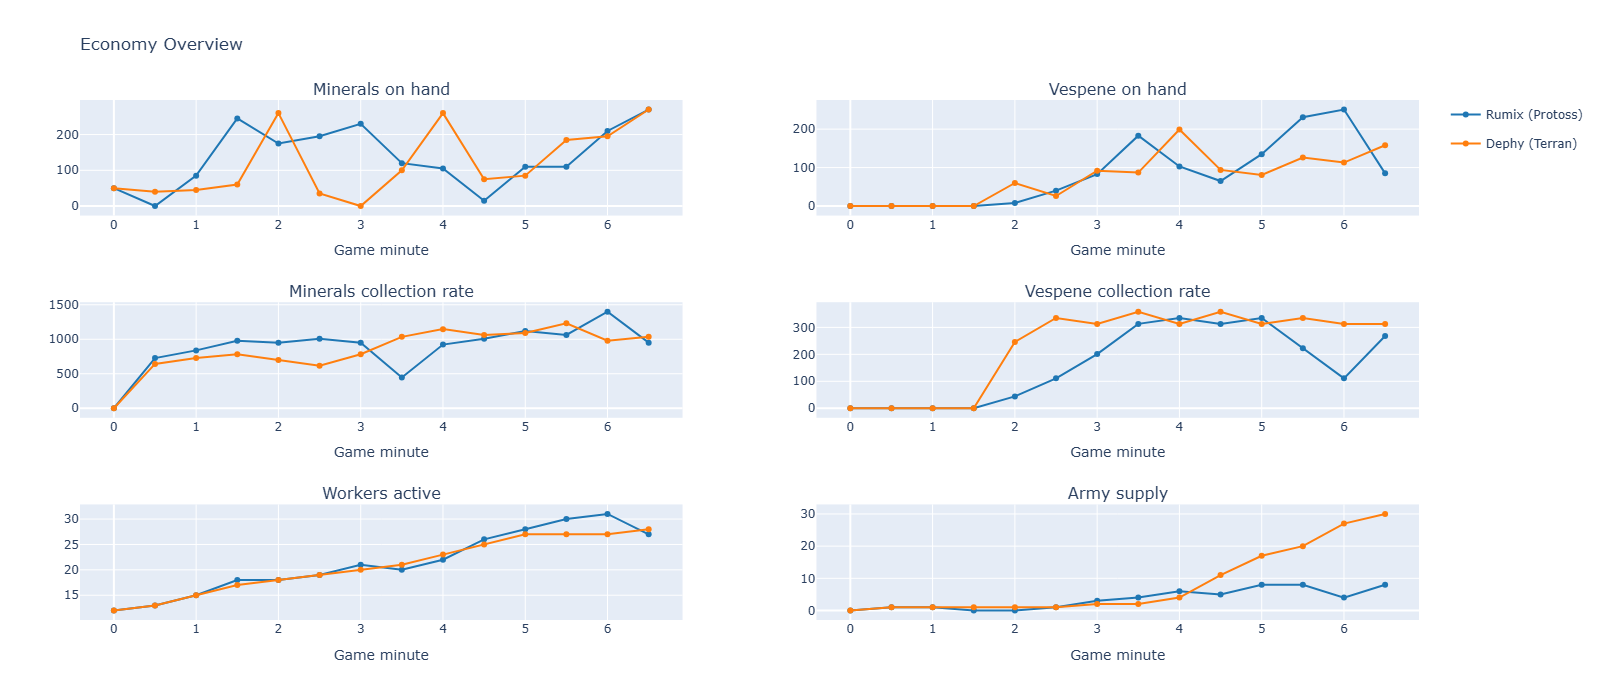

In [12]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Minerals on hand', 'Vespene on hand',
        'Minerals collection rate', 'Vespene collection rate',
        'Workers active', 'Army supply',
    ]
)

metrics = [
    ('minerals_current',         1, 1),
    ('vespene_current',          1, 2),
    ('minerals_collection_rate', 2, 1),
    ('vespene_collection_rate',  2, 2),
    ('workers_active',           3, 1),
    ('army_supply',              3, 2),
]

colors = ['#1f77b4', '#ff7f0e']
shown_in_legend = set()

for col_name, row, col in metrics:
    for i, (pid, grp) in enumerate(snap.groupby('player_id')):
        label = player_label(pid)
        show_legend = label not in shown_in_legend
        fig.add_trace(
            go.Scatter(
                x=grp['minute'], y=grp[col_name],
                name=label,
                line=dict(color=colors[i % 2]),
                legendgroup=label,
                showlegend=show_legend,
            ),
            row=row, col=col
        )
        shown_in_legend.add(label)

fig.update_layout(
    height=700,
    title_text='Economy Overview',
    hovermode='x unified',
)
fig.update_xaxes(title_text='Game minute')
fig.show()

## 7. Army supply over time

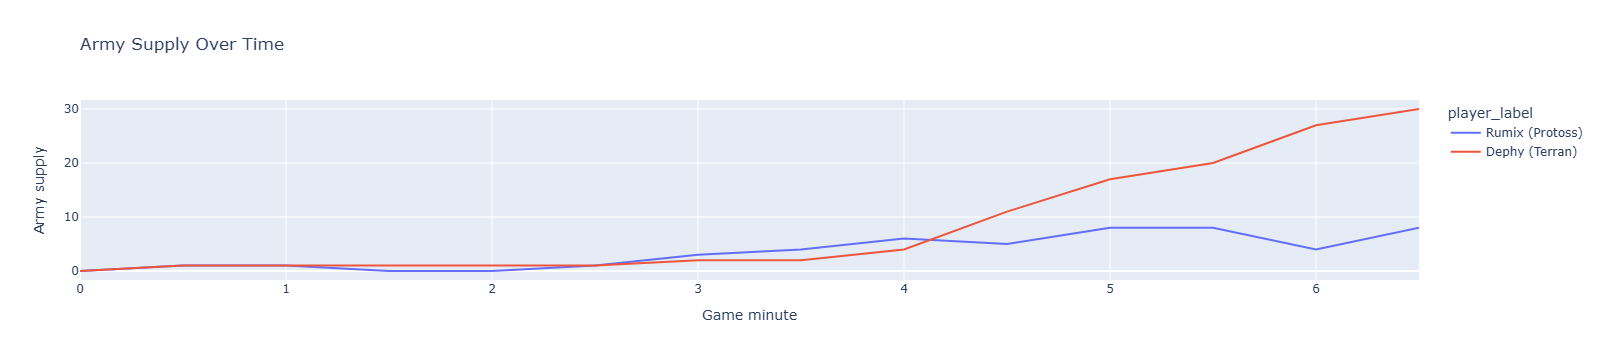

In [13]:
fig_army = px.line(
    snap, x='minute', y='army_supply',
    color='player_label',
    title='Army Supply Over Time',
    labels={'minute': 'Game minute', 'army_supply': 'Army supply'},
)
fig_army.show()

In [14]:
# build_all_checkpoints returns one dict per minute 
checkpoint_rows = build_all_checkpoints(replay)

df_single = pd.DataFrame(checkpoint_rows)
print(f'{len(df_single)} checkpoint rows for this replay')
df_single[['game_minute', 'p1_workers_active', 'p2_workers_active',
           'p1_army_supply', 'p2_army_supply',
           'delta_workers_active', 'delta_army_supply', 'winner']]

4 checkpoint rows for this replay


,game_minute,p1_workers_active,p2_workers_active,p1_army_supply,p2_army_supply,delta_workers_active,delta_army_supply,winner
0,3.0,21,20,3.0,2.0,1.0,1.0,2
1,4.0,22,23,6.0,4.0,-1.0,2.0,2
2,5.0,28,27,8.0,17.0,1.0,-9.0,2
3,6.0,31,27,4.0,27.0,4.0,-23.0,2


## 10. Batch-process all replays → training dataset  For every replay, we call `build_all_checkpoints()` which parses the replay once and returns one row per minute. 

In [15]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
from src.parser import parse_replay_file

N_WORKERS = min(10, multiprocessing.cpu_count() - 2)
print(f"Using {N_WORKERS} worker processes")

rows   = []
errors = []
done   = 0

args = [(p, None) for p in replay_files]  # None = use default checkpoints

print(f"Parsing {len(replay_files)} replays...")

with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = {pool.submit(parse_replay_file, a): a[0] for a in args}
    for future in as_completed(futures):
        checkpoint_rows, err = future.result()
        rows.extend(checkpoint_rows)
        if err:
            errors.append(err)
        done += 1
        if done % 500 == 0 or done == len(replay_files):
            print(f"  {done}/{len(replay_files)} done — {len(rows)} rows collected")

df_features = pd.DataFrame(rows)
df_features = df_features.dropna(subset=['winner'])
df_features['winner'] = df_features['winner'].astype(int)

print(f'\nReplays processed : {len(replay_files) - len(errors)}')
print(f'Errors            : {len(errors)}')
print(f'Total rows        : {len(df_features)}')
print(f'Checkpoints/game  : {df_features.groupby("replay_file").size().mean():.1f} avg')
print('\nRows per game minute:')
print(df_features['game_minute'].value_counts().sort_index())

Using 10 worker processes
Parsing 12000 replays...
  500/12000 done — 3663 rows collected
  1000/12000 done — 7183 rows collected
  1500/12000 done — 11025 rows collected
  2000/12000 done — 14896 rows collected
  2500/12000 done — 18191 rows collected
  3000/12000 done — 21991 rows collected
  3500/12000 done — 25841 rows collected
  4000/12000 done — 29543 rows collected
  4500/12000 done — 33111 rows collected
  5000/12000 done — 37024 rows collected
  5500/12000 done — 40184 rows collected
  6000/12000 done — 43635 rows collected
  6500/12000 done — 47984 rows collected
  7000/12000 done — 52693 rows collected
  7500/12000 done — 57184 rows collected
  8000/12000 done — 61894 rows collected
  8500/12000 done — 66554 rows collected
  9000/12000 done — 71361 rows collected
  9500/12000 done — 73582 rows collected
  10000/12000 done — 75602 rows collected
  10500/12000 done — 77632 rows collected
  11000/12000 done — 79747 rows collected
  11500/12000 done — 82354 rows collected
  120

In [16]:
out_path = Path('../data/features_checkpoints.csv')
out_path.parent.mkdir(exist_ok=True)
df_features.to_csv(out_path, index=False)
print(f'Saved {len(df_features)} rows to {out_path}')

Saved 84923 rows to ..\data\features_checkpoints.csv
